# To-Do:
1. Update gen_syn_locs to accept non-uniform dist and n_syn.
2. Add moving average to plotting.
3. Make building synapses separate (separate file or just from Class).
4. Clean up save/append old data.
5. Adjust homog spike train gen t_start for universal use.
6. Clean initW setting.
7. Make syn wt distr plot 
8. Add multi data plot
999. ...

In [1]:
import os, sys, csv, json, h5py, random, math, pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils

from modules import download_cell
from modules import build_cell
from modules import run_sim
from modules import plotting


--No graphics will be displayed.


# Download Cell

### Set Parameters

In [2]:
cell_name = 'PV' #SST, SST2, PV, PN

if os.path.isdir(f"cells/{cell_name}"): os.chdir(f"cells/{cell_name}") #else: create?

# http://celltypes.brain-map.org/mouse/experiment/electrophysiology/'specimen_id'
spec_ids = {'SST':476686112, 'SST2': 485466109, 'PV': 484635029}
specimen_id = spec_ids[cell_name] #SST 476686112, SST2 485466109, PV 484635029, 571709783
model_type = 'perisomatic' #or 'all active'

tunes_dir = 'tunes'
model_dir = 'seg_tuned' #f'OriginalFromAllenDB/{specimen_id}_{model_type}' # or None=tunes_dir

soma_diam_multis = {'SST':6, 'SST2':8, 'PV':6}
soma_diam_multiplier = soma_diam_multis[cell_name] #SST 6, SST2 8, PV 6

### Download Cell (if not already downloaded)

In [3]:
# (Optional) list available bundles for a specimen
download_cell.list_ADB_models(specimen_id)                             # all
download_cell.list_ADB_models(specimen_id, filter_type=model_type)  # filtered

# Download a bundle
cell_info = download_cell.download_ADB_cell(
    specimen_id=specimen_id,
    model_type=model_type,          # or "all active"
    tunes_dir=tunes_dir,    # base dir
    cache_stimulus=False,              # skip big NWB
    subdir=model_dir,          # None ='tunes_dir/', else ='tunes_dir'/'model_dir/'
    match="contains",                  # name matching behavior
    quiet=False,
)
cell_info["model_id"], cell_info["model_name"], cell_info["tunes_dir"]

# List the files you just pulled
len(cell_info["files"]), cell_info["files"][:5]

Models for specimen_id=484635029:
  485602029  Biophysical - perisomatic_Pvalb-IRES-Cre;Ai14-201791.05.01.01
  496538965  Biophysical - all active_Pvalb-IRES-Cre;Ai14-201791.05.01.01
Models for specimen_id=484635029:
  485602029  Biophysical - perisomatic_Pvalb-IRES-Cre;Ai14-201791.05.01.01
[download_ADB_cell] Found existing cache at: tunes/seg_tuned — skipping download.


(155,
 ['tunes/seg_tuned/484635029_fit.json',
  'tunes/seg_tuned/Pvalb-IRES-Cre_Ai14-201791.05.01.01_496079599_m.swc',
  'tunes/seg_tuned/Pvalb-IRES-Cre_Ai14-201791.05.01.01_496079599_marker_m.swc',
  'tunes/seg_tuned/manifest.json',
  'tunes/seg_tuned/modfiles/AMPA_NMDA_STP.mod'])

### Compile Modfiles

In [4]:
os.chdir(f'{tunes_dir}/{model_dir}')

# update_modfiles = None # or path/link to modfiles TODO
# if update_modfiles is not None:
#     !git clone update_modfiles

# if already compiled then lets delete the folder and force a recompile
if os.path.isdir('modfiles/x86_64'):
    os.system("rm -rf modfiles/x86_64")
# compile the mod files
if not os.path.isdir("modfiles/x86_64"): # Line redundant?
    # !nrnivmodl modfiles > /dev/null 2>&1
    os.chdir('modfiles')
    os.system("nrnivmodl")
    os.chdir("..")


from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")

/home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles
Mod files: "./AMPA_NMDA_STP.mod" "./CaDynamics.mod" "./Ca_HVA.mod" "./Ca_LVA.mod" "./GABA_A.mod" "./Ih.mod" "./Im.mod" "./Im_v2.mod" "./Kd.mod" "./K_P.mod" "./K_T.mod" "./Kv2like.mod" "./Kv3_1.mod" "./Nap.mod" "./NaTa.mod" "./NaTs.mod" "./NaV.mod" "./SK.mod" "./vecstim.mod"

Creating 'x86_64' directory for .o files.



/home/hrbncv/miniconda3/envs/BMTK/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
Translating AMPA_NMDA_STP.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/AMPA_NMDA_STP.c
Translating CaDynamics.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/CaDynamics.c
Translating Ca_HVA.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/Ca_HVA.c
Thread Safe
Thread Safe
Thread Safe
Translating Ca_LVA.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/Ca_LVA.c
Thread Safe
Translating GABA_A.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/GABA_A.c
Translating Ih.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/Ih.c
Translating Im.mod into /home/hrbncv/PV-SST/single_cells/cell

 -> Compiling mod_func.cpp
 -> NMODL ../AMPA_NMDA_STP.mod
 -> NMODL ../CaDynamics.mod
 -> NMODL ../Ca_HVA.mod
 -> NMODL ../Ca_LVA.mod
 -> NMODL ../GABA_A.mod
 -> NMODL ../Ih.mod
 -> NMODL ../Im.mod
 -> NMODL ../Im_v2.mod
 -> NMODL ../Kd.mod
 -> NMODL ../K_P.mod
 -> NMODL ../K_T.mod
 -> NMODL ../Kv2like.mod
 -> NMODL ../Kv3_1.mod
 -> NMODL ../Nap.mod
 -> NMODL ../NaTa.mod
 -> NMODL ../NaTs.mod
 -> NMODL ../NaV.mod
 -> NMODL ../SK.mod
 -> NMODL ../vecstim.mod
 -> Compiling AMPA_NMDA_STP.c
 -> Compiling CaDynamics.c
 -> Compiling Ca_HVA.c
 -> Compiling Ca_LVA.c
 -> Compiling GABA_A.c
 -> Compiling Ih.c
 -> Compiling Im.c
 -> Compiling Im_v2.c
 -> Compiling Kd.c
 -> Compiling K_P.c
 -> Compiling K_T.c
 -> Compiling Kv2like.c
 -> Compiling Kv3_1.c
 -> Compiling Nap.c
 -> Compiling NaTa.c
 -> Compiling NaTs.c
 -> Compiling NaV.c
 -> Compiling SK.c
 -> Compiling vecstim.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created 

1.0

In [5]:
################ stim_synapses functions ################
class AllenCell:
    
    ############### Cell Generation Functions ###############
    def __init__(self, gid, soma_diam_multiplier=1.0):
        # from allensdk.model.biophys_sim.config import Config
        # from allensdk.model.biophysical.utils import Utils
        # from neuron import h
        
        self._gid = gid
        self.synapses = []  # Keep track of all synapses
        self.netcons = []   # Keep track of NetCons
        self.stims = []     # Keep VecStims so they don't get garbage-collected
        self.vecs = []
        self.syn_locs = [] 
        
        description = Config().load('manifest.json')

        self.utils = Utils(description)
        self.h = self.utils.h
        self.Vinit = self.utils.description.data['conditions'][0]['v_init']
        # Cast all genome values to float
        for d in self.utils.description.data['genome']:
            if 'value' in d:
                d['value'] = float(d['value'])

        # Load morphology and parameters
        morphology_path = description.manifest.get_path('MORPHOLOGY')
        self.utils.generate_morphology(morphology_path.encode('ascii', 'ignore'))
        self.utils.load_cell_parameters()
        self.setup_morphology(soma_diam_multiplier)
        self._build_section_list()
    
    def setup_morphology(self,soma_diam_multiplier):

        self.soma = self.h.soma
        self.h.soma[0].diam *= soma_diam_multiplier
        self.dend = list(self.h.dend) if hasattr(self.h, 'dend') else []
        self.apic = list(self.h.apic) if hasattr(self.h, 'apic') else []
        self.axon = list(self.h.axon) if hasattr(self.h, 'axon') else []
        from neuron import h

        # Step 1: Set distance origin once (assuming soma(0.5) is your origin)
        h.distance(0, self.soma[0](0.5))

        # Step 2: Classify dendrites into proximal/distal
        self.proximal_dend_segs = []
        self.distal_dend_segs = []

        for sec in self.dend:
            for seg in sec:
                if 20 < h.distance(seg) < 100:
                    self.proximal_dend_segs.append(seg)  
                elif  h.distance(seg) >= 100:
                    self.distal_dend_segs.append(seg)

    def _build_section_list(self):
        # from neuron import h
        self.all = h.SectionList()
        for sec in h.allsec():
            self.all.append(sec)


############### Synapse Generation Functions ###############


    def compute_corrected_weights(self,distances, target_dist_func, bandwidth=10):
        """
        Compute sampling weights that correct for anatomical bias and follow a target distribution.

        Parameters:
        - seg_list: list of (sec, loc, dist)
        - target_dist_func: function mapping distance → desired probability (e.g. scipy poisson.pmf)
        - bandwidth: KDE smoothing bandwidth (in µm)

        Returns:
        - normalized weights (np.array)
        """

        # Step 1: Estimate anatomical density using KDE
        kde = gaussian_kde(distances, bw_method=bandwidth / np.std(distances))
        anatomical_pdf = kde(distances)

        # Step 2: Evaluate target distribution at each distance
        target_pdf = target_dist_func(distances)

        # Step 3: Divide target by anatomical density to correct for bias
        raw_weights = target_pdf / (anatomical_pdf + 1e-12)

        # Step 4: Normalize
        weights = raw_weights / raw_weights.sum()

        return weights
    

    # def _lognormal_mu_sigma(self, mean, std):
    #     """Return μ and σ for np.random.lognormal given arithmetic mean & std."""
    #     mu  = math.log(mean**2 / math.sqrt(std**2 + mean**2))
    #     sig = math.sqrt(math.log(1 + (std**2 / mean**2)))
    #     return mu, sig
    def draw_syn_wt(self, syn_params):
        """Generate a synaptic weight from a lognormal distribution."""


        wt_mean = syn_params.get('wt_mean', syn_params.get('initW', 0.001))
        wt_std  = syn_params.get('wt_std', 0.0) * wt_mean   #scaled off mean, std = 0  → fixed

        if wt_std > 0:
            # mu_logn, sig_logn = self._lognormal_mu_sigma(wt_mean, wt_std)
            mu  = math.log(wt_mean**2 / math.sqrt(wt_std**2 + wt_mean**2))
            sig = math.sqrt(math.log(1 + (wt_std**2 / wt_mean**2)))
            draw_wt = lambda: np.random.lognormal(mu, sig)
        else:
            draw_wt = lambda: wt_mean

        syn_wt = draw_wt()

        return syn_wt
    


    def gen_syn_locs(
            self,
            n_syns,
            dens_eq,        # =lamda d: -0.015*d + 4.25, = lamda: 2.0 
            seg_list,
            ):
        
        """ Generate synapse locations by density distribution dens_eq  """
        
        import math, re, random
        # from neuron import h

        all_syn_locs = []   # Or could use self.syn_locs.append(seg), instead of later when generating syns

        h.distance(0, self.soma[0](0.5))

        ### Generate Synaptic Locations ###
        ## If based on number and probability distrubution
        if n_syns is not None:
            distances = [h.distance(seg) for seg in seg_list]
            weights = self.compute_corrected_weights(distances,dens_eq)

            for syn in range(n_syns):
                sec_seg = random.choices(seg_list, weights=weights, k=1)[0]
                self.syn_locs.append(sec_seg)
                all_syn_locs.append(sec_seg)

        ## If based on density distribution
        else:
            for seg in seg_list:
                seg_dist = h.distance(seg)                  # µm
                seg_len  = seg.sec.L / seg.sec.nseg         # µm

                syn_dens = dens_eq(seg_dist)                # Synapses per µm
                if syn_dens <= 0:                           # skip negative densities
                    print('NEGATIVE/0 SYN_DENS, NO SYN CREATED!!!')
                    continue

                n_syns = math.floor(syn_dens * seg_len)     #+ rng.random())
                # if n_syns == 0:
                #     print(f'no syns created for seg {seg}: dist {seg_dist}, len {seg_len}, dens {syn_dens}')

                for syn in range(n_syns):
                    self.syn_locs.append(seg)
                    all_syn_locs.append(seg)

                # for _ in range(n_syn):
                #     # random position within the segment’s bounds
                #     #      segment runs from seg.x-Δx to seg.x+Δx
                #     dx = (rng.random() - 0.5) * (1/seg.sec.nseg)
                #     loc = seg.x + dx
                #     syn_locs.append(SynLoc(seg.sec, loc, seg_dist + dx*seg.sec.L))

        return all_syn_locs



    def homogeneous_poisson_timestamps(self, rate_hz, t_start, duration_ms):
        """
        Generate spike times for a homogeneous Poisson process.

        Parameters:
            rate_hz (float): desired firing rate in Hz.
            duration_ms (float): total time to generate over, in milliseconds.

        Returns:
            spike_times (list of float): spike timestamps in ms.
        """
        spike_times = []
        t = t_start         # Start of stimulation
        while t < duration_ms:
            isi = np.random.exponential(1000.0 / rate_hz)  # ISI in ms
            t += isi
            if t < duration_ms:
                spike_times.append(t)
        return spike_times


    def inhomogeneous_poisson_through_num_points(self,lambdas, win_length):
        t = np.zeros(len(lambdas) * win_length)
        lambdas = np.divide(lambdas,1000/win_length)
        
        for i, lambd in enumerate(lambdas):

            num_points = np.random.poisson(lambd)

            if num_points >= win_length:
                t[i * win_length : (i + 1) * win_length] = 1
                continue

            random_inds = np.random.choice(a = np.arange(win_length), size = num_points, replace = False)
            spikes = np.zeros(win_length)
            spikes[random_inds] = 1
            t[i * win_length : (i + 1) * win_length] = spikes

        return t
    

    def gen_spike_times(
            self,
            sim_params,
            syn_params,
            # bio_stim_input,
    ):
        """ Generate spike trains (list of timestamps) for NetCon input. """

        # If constant firing rate, specified in syn_params
        if isinstance(syn_params['freq'], int) or isinstance(syn_params['freq'], float):
            spike_times = self.homogeneous_poisson_timestamps(
                            rate_hz=syn_params['freq'], 
                            t_start=sim_params['tstart'], # 0 if delayed after gen (2 lines down)
                            duration_ms=sim_params['tstop'])
            # spike_times = [spike_time + sim_params['tstart'] for spike_time in spike_times] # Add delay
        
        # If inhomogeneous based on bio data
        elif isinstance(syn_params['freq'], str):

            # file_loc = "../../../Madhu_Data/bio_cell_output"
            PFR = pd.read_csv(os.path.join(syn_params['freq']),delimiter=",")
            bio_stim_input = np.array(PFR['AvgFiringRate'][PFR['Time'] >0])

            spike_times = []

            # Generate baseline input until csv data stim
            baseline_factor = bio_stim_input[0]
            baseline_spike_times = self.homogeneous_poisson_timestamps(
                rate_hz=baseline_factor,
                t_start=sim_params['tstart'],
                duration_ms=sim_params['delay']
            )
            for spk in baseline_spike_times:
                spike_times.append(spk)

            # Generate stim input from csv
            # bio_stim_input = [avg_fq - baseline_factor for avg_fq in bio_stim_input]
            stim_spikes = self.inhomogeneous_poisson_through_num_points(
                            bio_stim_input,
                            int(sim_params['bins']))
            time = np.arange(len(stim_spikes))
            stim_spike_times = time[stim_spikes==1]
            stim_spike_times = [spk + sim_params['delay'] for spk in stim_spike_times] # Add delay

            for spk in stim_spike_times:
                spike_times.append(spk)
            
            # Generate baseline input after csv data stim
            # baseline_spike_times = self.homogeneous_poisson_timestamps(
            #     rate_hz=baseline_factor,
            #     t_start=sim_params['tstart'],
            #     duration_ms=sim_params['delay']
            # )
            # for spk in baseline_spike_times:
            #     spike_times.append(spk)


        else:
            print('Please use valid spike train input!')

        return spike_times


    def gen_syn_mechs(
            self,
            syn_loc,
            syn_params,
            ):
        """ Generate syn_name synapse with parameters syn_params. """

        # from neuron import h
        syn_type = syn_params['type']
        # print(f'syn_type: {type(syn_type)} | syn_loc: {syn_loc}')
        syn = getattr(h, syn_params['type'])(syn_loc)
        for param, val in syn_params.items():
            # if param in ('wt_mean', 'wt_std'): # Skip certain keys
            #     continue
            if hasattr(syn, param):
                setattr(syn, param, val)
        syn_wt = self.draw_syn_wt(syn_params)
        syn.initW = syn_wt
        # print(syn.initW)

        return syn



    def gen_syns(
            self,
            syn_params,
            # bio_stim_input,
            sim_params,
            ):
        """ Generate syn_name synapses with parameters syn_params for segments in seg_list. """

        # from neuron import h

        syn_records = {}    # list of dicts we will optionally return
        syn_id = 0

        ### Generate synapses for each syn group in syn_params ###
        for syn_group in syn_params:
            if syn_params[syn_group]['N_syn'] is not None:
                if syn_params[syn_group]['N_syn'] < 1:
                    continue
                
            # Create record lsit for group
            syn_records[syn_group] = []

            # Get syn_params for group
            syn_params_group = syn_params[syn_group]

            # Determine which dendrite sections for group syns
            syn_segs = syn_params_group['segs']
            if syn_segs == 'all':
                seg_list = self.proximal_dend_segs + self.distal_dend_segs
            elif syn_segs == 'proximal':
                seg_list = self.proximal_dend_segs
            elif syn_segs == 'distal':
                seg_list = self.distal_dend_segs
            elif syn_segs == 'soma':
                seg_list = self.soma
            else:
                print('NO DENDRITE SECTIONS SELECTED!!!')


            ### Generate synaptic locations ###
            all_syn_locs = self.gen_syn_locs(
                                n_syns = syn_params_group['N_syn'], 
                                dens_eq = syn_params_group['dist_func'], 
                                seg_list = seg_list,
                                )
            

            for syn_loc in all_syn_locs:
                ### Generate synaptic mechanisms ###
                syn = self.gen_syn_mechs(syn_loc, syn_params_group)
                self.synapses.append(syn)

                ### Generate synaptic input (spike trains) ###
                spike_times = self.gen_spike_times(
                                    sim_params, 
                                    syn_params_group,
                                    )

                ### Generate NetCon & Stimulation ###
                vec = h.Vector(spike_times)
                stim = h.VecStim()
                stim.play(vec)
                nc = h.NetCon(stim, syn)
                nc.weight[0] = 1 
                
                # self.synapses.append(syn)
                self.vecs.append(vec)
                self.stims.append(stim)
                self.netcons.append(nc)


                ### Generate synaptic record ###
                syn_records[syn_group].append({    # Could add more, or auto from syn_params_group/h.
                    "syn_id": syn_id,
                    "group": syn_group,
                    "type": syn_params_group['type'],
                    "weight": syn.initW,
                    "distance": h.distance(syn_loc),
                    "section": syn_loc.sec.name(),
                    "x": syn_loc.x,
                    "spike_times": spike_times,
                    # "NMDA_ratio": nmda_wt, # EXAMPLE, FOR FUTURE
                })
                # print(f'synapse {syn_id} generated: {syn_records[syn_group][-1]}')
                syn_id = syn_id + 1
                
            print(f'{syn_group} synapses generated: {len(all_syn_locs)}')

        return syn_records



    def __str__(self):
        return f"AllenCell(soma={self.soma}, dendrites={len(self.dend)})"



############ Other cell building functions #############


# Synaptic Parameters

In [6]:
syn_params = {

    ############################ PV ############################
    'PV': {
        'stim': {
                'type': "AMPA_NMDA_STP",
                'N_syn': None, # num of syns generated; if None uses dist_func
                'segs': 'all', # 'all', 'proximal', 'distal'
                'dist_func': lambda d: (-0.015*d + 4.25)*0.02, # *0.02 to scale to 50
                'freq': '/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv', # constant, or .csv fp for inhomog input

                'wt_mean': 1.5, 
                'wt_std': (0.25/0.75), # bio data shows about 0.25/0.75 of mean

                'initW': 1.0,
                'gmax_AMPA': 0.001, #uS
                'gmax_NMDA': 0.001, #uS
                'tau_r_AMPA': 3.5,
                'tau_d_AMPA': 4,
                'Use': 0.80,
                'Dep': 100.0, #130
                'Fac': 0.0,
                'NMDA_ratio': 0.0
            },

        'bg_exc': {
                'type': "AMPA_NMDA_STP",
                'N_syn': None,
                'segs': 'all',              
                'dist_func': lambda d: (-0.015*d + 4.25) * 0.8, # 80% exc bg
                'freq': 0.01, 

                'wt_mean': 1.5, # 0.07 with 2Hz is right range
                'wt_std': (0.25/0.75), # µS, not sure what ratio for bg

                'initW': 1.0,
                'gmax_AMPA': 0.001, #uS
                'gmax_NMDA': 0.001, #uS
                'tau_r_AMPA': 3.5,
                'tau_d_AMPA': 4,
                'Use': 0.80,
                'Dep': 100.0, #130
                'Fac': 0.0,
                'NMDA_ratio': 0.0
            },

        'bg_inh': {
                'type': "GABA_A",
                'N_syn': None,    
                'segs': 'all',
                'dist_func': lambda d: (-0.015*d + 4.25) * 0.2, # 20% exc bg
                'freq': 1.0,

                'wt_mean': 1.5,
                'wt_std': (0.25/0.75),

                'initW': 1.0,
                'gmax': 0.001, #uS
                'tau_r_GABAA': 0.5,
                'tau_d_GABAA': 5.5,
            },
        },

    ############################ SST ############################
    # 'SST2': {
    #     'stim': {
    #             'type': "AMPA_NMDA_STP",
    #             'N_syn': 50, # num of syns generated; if None uses dist_func
    #             'segs': 'all', # 'all', 'proximal', 'distal'
    #             'dist_func': lambda d: 2.0,
    #             'freq': '/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv', # constant, or .csv fp for inhomog input

    #             'wt_mean': 0.2, 
    #             'wt_std': (0.17/0.5), # bio data shows about 0.17/0.5 of mean

    #             'initW': 1.0,
    #             'gmax_AMPA': 0.001, #uS
    #             'gmax_NMDA': 0.001, #uS
    #             'tau_r_AMPA': 4,
    #             'tau_d_AMPA': 5,
    #             'Use': 0.4,
    #             'Dep': 0,
    #             'Fac': 70, #80
    #             'NMDA_ratio': 1.5
    #         },

    #     'bg_exc': {
    #             'type': "AMPA_NMDA_STP",
    #             'N_syn': None,              # num of syns generated; if None uses dist_func
    #             'segs': 'all',              # 'all', 'proximal', 'distal'
    #             'dist_func': lambda d: (2.0) * 0.8,
    #             'freq': 0.3, #0.2/0.275 integer (Hz), if constant; or .csv name for inhomog input

    #             'wt_mean': 0.2, #0.1/0.5 µS   0.07 with 2Hz is right range
    #             'wt_std': (0.17/0.5), # µS, not sure what ratio for bg

    #             'initW': 1.0,
    #             'gmax_AMPA': 0.001, #uS
    #             'gmax_NMDA': 0.001, #uS
    #             'tau_r_AMPA': 4,
    #             'tau_d_AMPA': 5,
    #             'Use': 0.4,
    #             'Dep': 0,
    #             'Fac': 70,
    #             'NMDA_ratio': 1.5
    #         },

    #     'bg_inh': {
    #             'type': "GABA_A",
    #             'N_syn': None,
    #             'segs': 'all',
    #             'dist_func': lambda d: (2.0) * 0.2,
    #             'freq': 0.1, #0.2/0.275

    #             'wt_mean': 0.2, #0.1/0.5 µS 
    #             'wt_std': (0.17/0.5),

    #             'initW': 1.0,
    #             'gmax': 0.001, #uS
    #             'tau_r_GABAA': 0.5,
    #             'tau_d_GABAA': 5.5,
    #         },
    #     },
}
syn_params = syn_params[cell_name]


# Set sim parameters
sim_params = {
    'dt': 0.025, # ms
    'delay': 300.0, #ms
    'tstart': 00.0, # ms
    'tstop': 1000.0, # ms
    'bins': 5, # ms; for spike train gen/sim, not plotting
}

# Read In Data

In [7]:
# Read in bio data if applicable
file_loc = "/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output"
PFR = pd.read_csv(os.path.join(file_loc,"pyrFiringRateAvg.csv"),delimiter=",")

PFR_time_shortened = np.array(PFR['Time'][PFR['Time'] >0])
delayed_PFR_t = np.array([pfrt + (sim_params['delay']/1000) for pfrt in PFR_time_shortened])
PFR_firing_rate_shortened = np.array(PFR['AvgFiringRate'][PFR['Time'] >0])

# Synaptic Stim Sim

### Build Cell & Add Synapses

In [8]:
cell = AllenCell(0,soma_diam_multiplier)
# print(cell.soma[0])

syn_records = cell.gen_syns(
    syn_params = syn_params,
    sim_params = sim_params,
)

stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953


### Analyze Cell & Synapse Generation

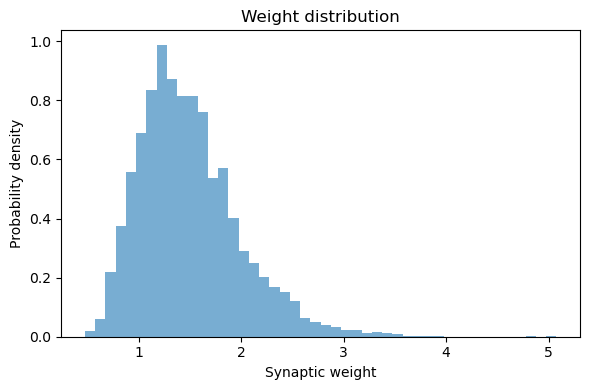

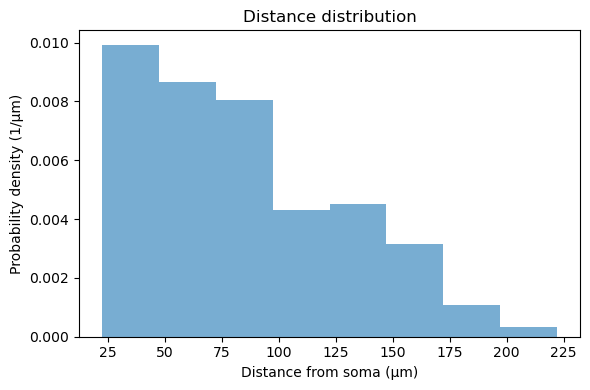

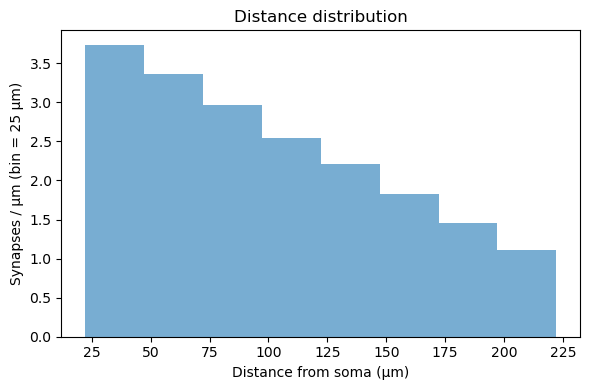

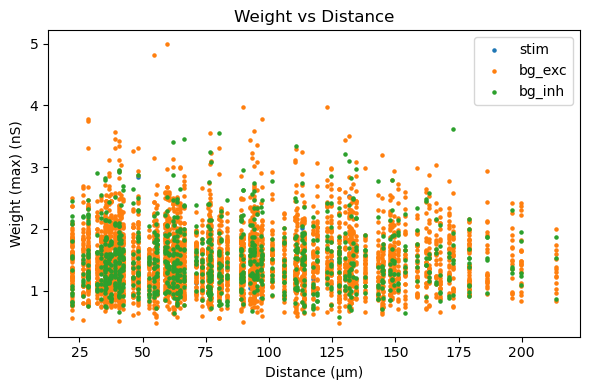

Summary: 
Mean distance: 84.8 µm 
Min distance:  22.2 µm 
Max distance:  213.5 µm 
skew: 0.6307148136824098 (uniform = 0) 
kurtosis: -0.48630350965572866 (uniform is 1.8, or -1.2 if excess kurtosis)
common sections = set()


In [9]:
plotted_groups = list(syn_records.keys())
# plotted_groups = ['bg_exc', 'bg_inh','stim',]
plotted_groups = ['all']

## Plot synaptic weight distribution
plotting.plot_syn_records(
    cell,
    syn_records,
    plotted_groups = plotted_groups, #['bg_exc', 'bg_inh','stim',], #'stim', 
    plotted_props = ['weight_probability'],
    color=None, # 'color' or None
    plot_type='hist',           # 'line', 'hist', 'both'
    bins = 0.1,
    win_size=0.1,
    fig_sizes = (6,4),
    )

## Plot synaptic disctance distribution
plotting.plot_syn_records(
    cell,
    syn_records,
    plotted_groups = plotted_groups, #['bg_exc', 'bg_inh','stim',], #'stim',
    plotted_props = ['distance_probability'],
    color=None,
    plot_type='hist', 
    bins = 25,
    win_size=50,
    fig_sizes = (6,4),
    )

plotting.plot_syn_records(
    cell,
    syn_records,
    plotted_groups = plotted_groups, #['bg_exc', 'bg_inh','stim',], #'stim',
    plotted_props = ['distance_density'],
    color=None,
    plot_type='hist', 
    bins = 25,
    win_size=50,
    fig_sizes = (6,4),
    )

## Plot synaptic weight & distance scatter
plotted_groups = list(syn_records.keys())
plotting.plot_syn_records(
    cell,
    syn_records,
    plotted_groups = plotted_groups, #['bg_exc', 'bg_inh','stim',], #'stim',
    plotted_props=['weight','distance'],
    fig_sizes = (6,4),
    )



from scipy.stats import skew
from scipy.stats import kurtosis

distances = [h.distance(loc) for loc in cell.syn_locs]

print("Summary: \n" \
    f"Mean distance: {sum(distances)/len(distances):.1f} µm \n" \
    f"Min distance:  {min(distances):.1f} µm \n" \
    f"Max distance:  {max(distances):.1f} µm \n" \
    f"skew: {skew(distances)} (uniform = 0) \n" \
    f"kurtosis: {kurtosis(distances)} (uniform is 1.8, or -1.2 if excess kurtosis)")

#make sure sections are not reused in other section lists
common_sections = set(cell.proximal_dend_segs) & set(cell.distal_dend_segs)
print(f"common sections = {common_sections}")

In [10]:
# err

### Run Sim

In [11]:
sim_traces = run_sim.run_cell(cell,sim_params) #,I,G
T = sim_traces['T']
V = sim_traces['V']
I = sim_traces['I']
G = sim_traces['G']
# plt.plot(T,I)
# plt.plot(T,G)

### Run Spike Detection and Plot

Detected 8 spikes (total avg: 8.88888888888889) at times (ms): [ 99.825 138.7   423.725 475.475 524.25  612.45  747.425 827.475]


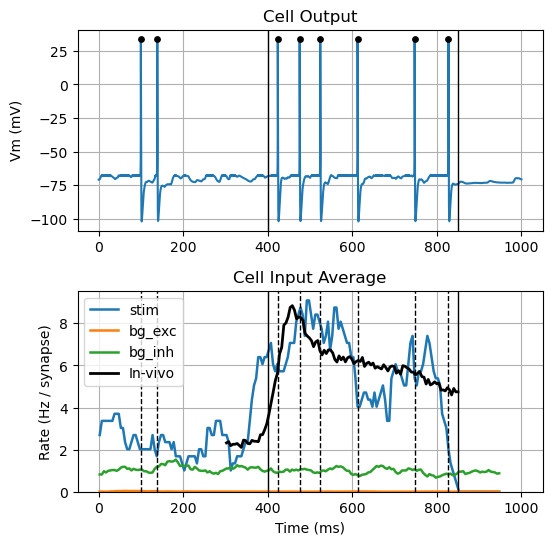

In [12]:
win_size = 50

plotting.plot_single_run(
    T, V,
    syn_records,
    sim_params,
    win_size = win_size, # None
    rate_style   = 'line',      # 'hist' | 'line' | 'both' | None
    raster_style = None,       # 'dot' | 'line' | None
    col = None,
    in_vivo_curve = (delayed_PFR_t, PFR_firing_rate_shortened)  # or None
)


In [13]:
output_fn = 'tune1_singlerun'
output_fp = os.path.join("output_data", output_fn + ".pkl")

save_single_data = False
if save_single_data and not os.path.exists(output_fp):
    with open(output_fp, "wb") as f:
        pickle.dump(sim_traces, f)
    print(f'data saved as {output_fp}')


load_single_data = False
if load_single_data:
    with open(output_fp, "rb") as f:
        old_sim_traces = pickle.load(f)
    
    plotting.plot_single_run(
        old_sim_traces['T'], old_sim_traces['V'],
        syn_records,
        sim_params,
        win_size = 50, # None
        rate_style   = 'line',      # 'hist' | 'line' | 'both' | None
        raster_style = None,       # 'dot' | 'line' | None
        col = None,
        in_vivo_curve = (delayed_PFR_t, PFR_firing_rate_shortened)  # or None
    )



In [14]:
err

NameError: name 'err' is not defined

# Multi-Trial Parametric Analysis

### Run Parametric Analysis

In [ ]:
cell = AllenCell(0,soma_diam_multiplier)


param_study = {
    'input_type': None,   # None, list of syn_groups, ['stim', 'bg_exc', 'bg_inh', 'all']
    'param_type': None,  # None, any var in syn_params
    'param_vals': ['base tune'],  
    'n_trials': 10, # Number of trials per param
}

all_param_data, all_syn_records = run_sim.run_param_analysis(
                                    cell,
                                    sim_params,
                                    syn_params,
                                    param_study,
                                )

stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 1 | 10 spikes  ⇒  10.00 Hz
stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 2 | 9 spikes  ⇒  9.00 Hz
stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 3 | 7 spikes  ⇒  7.00 Hz
stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 4 | 10 spikes  ⇒  10.00 Hz
stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 5 | 13 spikes  ⇒  13.00 Hz
stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 6 | 6 spikes  ⇒  6.00 Hz
stim synapses generated: 54
bg_exc synapses generated: 3933
bg_inh synapses generated: 953
param: base tune | trial: 7 | 7 spikes  ⇒  7.00 Hz


### Plot Parametric Analysis

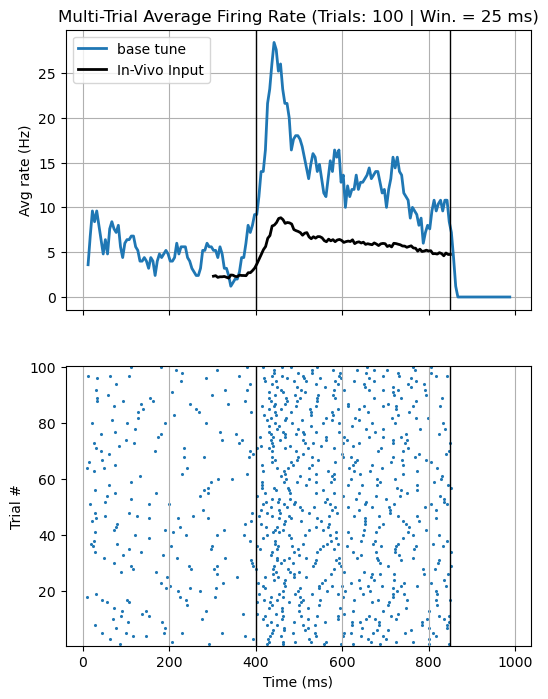

In [ ]:
win_size = 25

plotting.plot_param_study(all_param_data,
                  param_study,
                  sim_params,
                  win_size=win_size, # None
                  plot_type = 'line', # 'hist' | 'line' | 'both' | 'kde' | 'hist_kde'
                  plot_bio = (True, delayed_PFR_t, PFR_firing_rate_shortened),
                  plot_raster = True, raster_style='dot', # 'dot' or 'line'
)

# Save/Plot Old Data

### Save Parametric Analysis Data

In [ ]:
save_data = False
output_fn = 'tune1_10tr1000ms'
output_fp = os.path.join("output_data", output_fn + ".pkl")

# if param_study['param_type'] == None:
#     output_fn = 'bg...'

if save_data and not os.path.exists(output_fp):
    with open(output_fp, "wb") as f:
        pickle.dump(all_param_data, f)
    print(f'data saved as {output_fp}')

#################################################################

append_data = False

old_fn      = 'tune1_900tr1000ms'
old_fn2     = None #'tune1_50tr1000ms'

new_fn      = 'tune1_1000tr1000ms'


if append_data:
    old_fp = os.path.join("output_data", old_fn + ".pkl")
    with open(old_fp, "rb") as f:
        all_param_data_old = pickle.load(f)

    if old_fn2 is not None:
        old_fp2 = os.path.join("output_data", old_fn2 + ".pkl")
        with open(old_fp2, "rb") as f:
            added_data = pickle.load(f)
    else:
        added_data = all_param_data

    for param, new_trials in added_data.items():     # new_trials = list
        if param in all_param_data_old:
            all_param_data_old[param].extend(new_trials) 
        else:
            all_param_data_old[param] = list(new_trials)

    new_fp = os.path.join("output_data", new_fn + ".pkl")
    with open(new_fp, "wb") as f:
        pickle.dump(all_param_data_old, f)

    print(f"Updated {len(all_param_data_old)} parameter values for {old_fp} → {new_fp}")

Updated 1 parameter values for output_data/tune1_900tr1000ms.pkl → output_data/tune1_1000tr1000ms.pkl


### Plot Old Parametric Analysis Data

<class 'numpy.ndarray'>


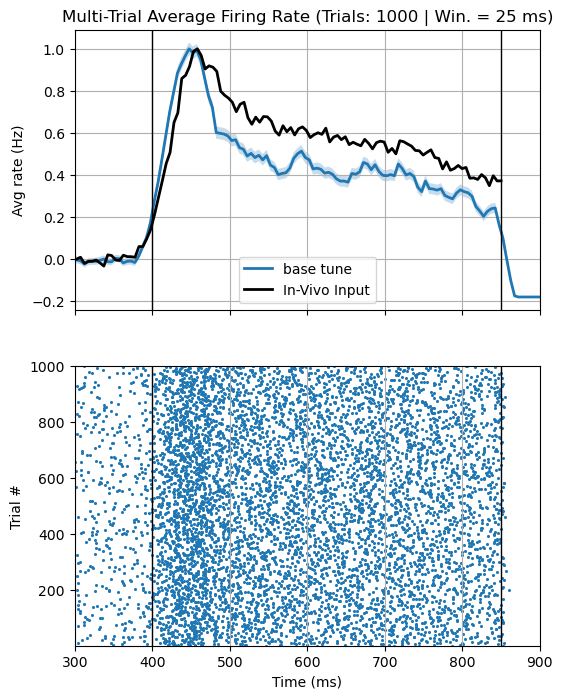

In [16]:
plot_old_data = True
# output_fn = 'tune1_150trials1000ms'
output_fn = 'tune1_1000tr1000ms'
output_fp = os.path.join("output_data", output_fn + ".pkl")

if plot_old_data:

    with open(output_fp, "rb") as f:
        all_param_data_old = pickle.load(f)

    subset_n = None
    if subset_n is not None:
        for param_val in all_param_data_old:
            all_param_data_old[param_val] = all_param_data_old[param_val][:subset_n]
    
    old_param_study = {
        'input_type': None,   # None, list of syn_groups, ['stim', 'bg_exc', 'bg_inh', 'all']
        'param_type': None,     # None, any var in syn_params
        'param_vals': list(all_param_data_old.keys()), # param_vals from param_data
        'n_trials': len(all_param_data_old['base tune']),         # Number of trials per param
        }

    old_sim_params = {
        'dt': 0.025, # ms
        'delay': 300.0, #ms
        'tstart': 100.0, # ms
        'tstop': 1000.0, # ms
        'bins': 5, # ms; for spike train gen/sim, not plotting
    }
    win_size = 25
    
    plotting.plot_param_study(all_param_data_old,
                old_param_study,
                old_sim_params,
                win_size=win_size, # None
                plot_type = 'line', # 'hist' | 'line' | 'both'
                plot_bio = (True, delayed_PFR_t, PFR_firing_rate_shortened),
                plot_raster = True, raster_style='dot', # 'dot' or 'line'
                plot_window = {'x': (300, old_sim_params['delay']+600), 
                               'y': (None, None)},
                norm_fr = -4, # -8,-3.5
                shade_mode = 'sem',
                set_color = None,
)

In [ ]:
all_param_data_old

{'base tune': [array([ 57.525, 286.175, 462.4  , 547.325, 612.075, 683.   , 711.5  ,
         743.95 , 787.05 , 852.9  ]),
  array([ 54.925, 348.725, 420.825, 455.75 , 520.275, 564.2  , 599.825,
         705.425]),
  array([429.075, 463.75 , 521.475, 599.35 , 722.45 , 764.05 ]),
  array([142.975, 432.75 , 449.125, 566.05 , 649.025, 797.65 ]),
  array([361.325, 420.95 , 463.075, 513.45 , 618.975, 695.55 , 846.125]),
  array([191.15 , 392.575, 437.   , 479.425, 594.05 , 666.075]),
  array([250.15 , 426.325, 446.425, 697.7  , 800.775]),
  array([284.75 , 428.575, 484.55 , 516.075, 585.675, 680.525, 738.425,
         799.075]),
  array([157.45 , 303.975, 428.175, 447.35 , 582.825, 608.425, 674.5  ,
         744.4  , 799.875, 820.85 ]),
  array([206.95 , 409.45 , 466.   , 589.725, 656.6  ]),
  array([ 19.975, 297.075, 346.25 , 425.575, 459.125, 508.275, 579.45 ,
         638.275, 722.6  , 766.825, 829.25 ]),
  array([232.6  , 415.775, 452.825, 551.075, 604.7  , 681.3  , 729.45 ,
         77

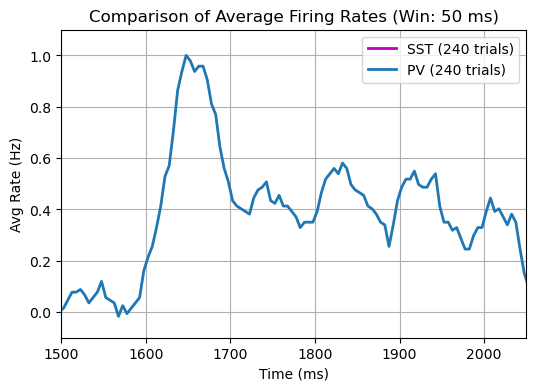

In [ ]:
plotted_files = {
    'SST': {
        'data': '/home/hrbncv/PV-SST/single_cells/cells/SST2/output_data/tune1_240trials1000ms.pkl',
        'dur': 2500,
        'norm_fr': -7,
        'color': 'm',
        },

    'PV': {
        'data': '/home/hrbncv/PV-SST/single_cells/cells/PV/output_data/baseadj_240trials2500ms.pkl',
        'dur': 2500,
        'norm_fr': -3,
        'color': None,
        },
}

plotting.plot_compare_multi(plotted_files,
            sim_params,
            win_size=50, # None
            plot_bio = (False, delayed_PFR_t, PFR_firing_rate_shortened),
            plot_window = {'x': (1500,2050), 'y': (-0.1,1.1)},
            shade_mode = None #'sem'
)